# **Part 1: Problem Discovery**

**Business problem:** “Given historical Superstore sales, what’s the probability we’ll hit $50,000 revenue next quarter, and what revenue range should we plan for (50% and 90% CIs)?”
Who cares / why: Sales & ops—inventory, staffing, and cash planning need a range, not a point.
Monte Carlo fit: Demand and order mix vary; we’ll simulate many plausible quarters from empirical distributions.

**Dataset link to submit:** Tableau Sample Superstore (XLS/CSV) on Kaggle
https://www.kaggle.com/datasets/dougvernon/tableau-sample-superstore


# **Part 2 — Monte Carlo Analysis in Google Colab (Sample Superstore)**

This notebook implements all required components for Part 2 of your assignment using the Tableau Sample Superstore dataset.

**What you'll do here**
1. **Data Loading & Exploration** (EDA)
2. **Model Definition** (clear equation)
3. **Distribution Identification** (histograms + Q–Q plots)
4. **Monte Carlo Simulation** (≥10,000 runs)
5. **Statistical Analysis** (mean, CI, probabilities, VaR)
6. **Visualizations** (histogram, boxplot, CDF, +1 extra)
7. **Documentation** (explanations & interpretations)

> **Dataset**: “Sample Superstore”. If you don't already have it, download the CSV (or Excel) and upload it to your Colab session. You can also point to a file in Google Drive.



> **Requirements to run locally/Colab**
```
pip install pandas numpy scipy matplotlib seaborn plotly
```



## 1) Data Loading & Exploration

**Goal:** Load the dataset, create daily aggregates, and explore variability (seasonality, distributions).

- We'll compute **Orders per Day**, **AOV (Average Order Value) per Day**, and **Sales per Day**.
- For a time-bounded forecast (e.g., next quarter), we'll optionally **filter historical data to the same quarter months** to avoid seasonality bias.


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving SampleSuperstore.csv.xls to SampleSuperstore.csv.xls
User uploaded file "SampleSuperstore.csv.xls" with length 3364352 bytes



Daily DataFrame head after aov_per_day calculation:


,date,sales_per_day,orders_per_day,aov_per_day
0,2014-01-03,16.448,1,16.448000
1,2014-01-04,288.060,1,288.060000
2,2014-01-05,19.536,1,19.536000
3,2014-01-06,4407.100,3,1469.033333
4,2014-01-07,87.158,1,87.158000



Daily DataFrame info after aov_per_day calculation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            1237 non-null   object 
 1   sales_per_day   1237 non-null   float64
 2   orders_per_day  1237 non-null   int64  
 3   aov_per_day     1237 non-null   float64
dtypes: float64(2), int64(1), object(1)
memory usage: 38.8+ KB


,date,sales_per_day,orders_per_day,aov_per_day
0,2014-01-03,16.448,1,16.448000
1,2014-01-04,288.060,1,288.060000
2,2014-01-05,19.536,1,19.536000
3,2014-01-06,4407.100,3,1469.033333
4,2014-01-07,87.158,1,87.158000


Date range: 2014-01-03 to 2017-12-30
                 count         mean          std    min      25%       50%  \
sales_per_day   1237.0  1857.074261  2305.538776  2.025  377.736  1063.185   
orders_per_day  1237.0     4.049313     2.845253  1.000    2.000     3.000   
aov_per_day     1237.0   455.199385   613.792410  2.025  147.934   300.512   

                      75%           max  
sales_per_day   2395.7860  28106.716000  
orders_per_day     5.0000     19.000000  
aov_per_day      553.0455   9368.905333  


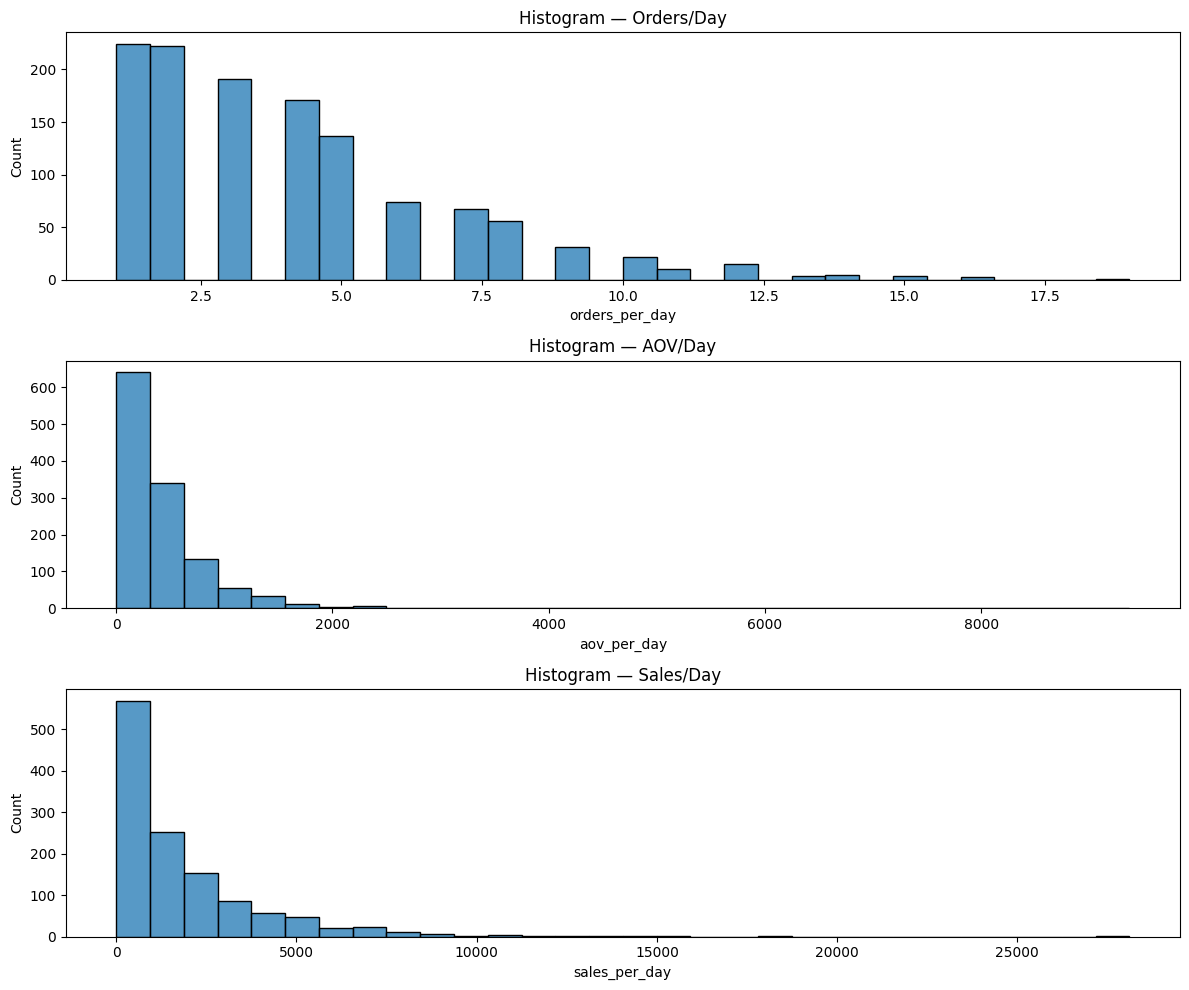

In [ ]:
# --- Imports & settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import kagglehub
from kagglehub import KaggleDatasetAdapter

pd.set_option('display.max_columns', None)

# --- USER INPUTS ---
# Provide your file path here. Example options:
# 1) If you upload to Colab files: "/content/SampleSuperstore.xls" # Corrected file extension
# 2) If using Google Drive, mount and set the path accordingly.
FILE_PATH = "/content/SampleSuperstore.csv.xls"  # <- change if needed

# Choose seasonal filter (months) to match your target quarter (optional)
# Example: Q1 months = [1, 2, 3], Q2 = [4, 5, 6], etc.
SEASON_MONTHS = None  # e.g., [1, 2, 3] for Q1 or leave as None for all history

# --- Load data ---
# Load the data from the specified file path
df = pd.read_excel(FILE_PATH)


# Try to find likely column names
date_col_candidates = [c for c in df.columns if 'date' in c.lower()]
sales_col_candidates = [c for c in df.columns if 'sales' in c.lower()]

if not date_col_candidates or not sales_col_candidates:
    raise ValueError("Couldn't find date/sales columns automatically. Please check your CSV and set the correct column names below.")

ORDER_DATE_COL = date_col_candidates[0]
SALES_COL = sales_col_candidates[0]

# Parse dates
df[ORDER_DATE_COL] = pd.to_datetime(df[ORDER_DATE_COL])

# Optionally seasonal filter
if SEASON_MONTHS is not None:
    df = df[df[ORDER_DATE_COL].dt.month.isin(SEASON_MONTHS)].copy()

# Create daily aggregates
daily = (df
         .groupby(df[ORDER_DATE_COL].dt.date)
         .agg(
             sales_per_day=(SALES_COL, 'sum'),
             orders_per_day=('Order ID' if 'Order ID' in df.columns else df.columns[0], 'nunique')
         )
         .reset_index()
         .rename(columns={ORDER_DATE_COL: 'date'}))

# Compute AOV (Average Order Value) per day
daily['aov_per_day'] = daily['sales_per_day'] / daily['orders_per_day']

# --- Debugging: Display head and info after calculating aov_per_day ---
print("\nDaily DataFrame head after aov_per_day calculation:")
display(daily.head())
print("\nDaily DataFrame info after aov_per_day calculation:")
daily.info()
# --- End Debugging ---


display(daily.head())

# Basic EDA
print("Date range:", daily['date'].min(), "to", daily['date'].max())
print(daily[['sales_per_day','orders_per_day','aov_per_day']].describe().T)

# Visual quick looks
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
sns.histplot(daily['orders_per_day'], bins=30, ax=axes[0]); axes[0].set_title("Histogram — Orders/Day")
sns.histplot(daily['aov_per_day'], bins=30, ax=axes[1]); axes[1].set_title("Histogram — AOV/Day")
sns.histplot(daily['sales_per_day'], bins=30, ax=axes[2]); axes[2].set_title("Histogram — Sales/Day")
plt.tight_layout(); plt.show()


## 2) Model Definition

We model **Quarterly Revenue** as the sum of daily revenues over ~90 days:

\[\
\textbf{QuarterRevenue} = \sum_{d=1}^{90} (\text{Orders}_d \times \text{AOV}_d)\
\]

- **Dependent variable:** Quarterly revenue
- **Independent variables:** Orders/day, AOV/day
- **Constants:** Number of days in target period (e.g., 90)
- We'll simulate daily **Orders** and **AOV** using **empirical bootstrap** (default) or **parametric** distributions.



## 3) Distribution Identification

Two approaches (both acceptable per rubric):

1. **Empirical (bootstrap)**: resample historical daily values with replacement (season-matched if you filtered). This avoids mis-fitting and is fast.
2. **Parametric**:
   - Orders/day → **Poisson(λ)**
   - AOV/day → **Lognormal(μ, σ)** on log(AOV)

We’ll include Q–Q plots for sanity checks.


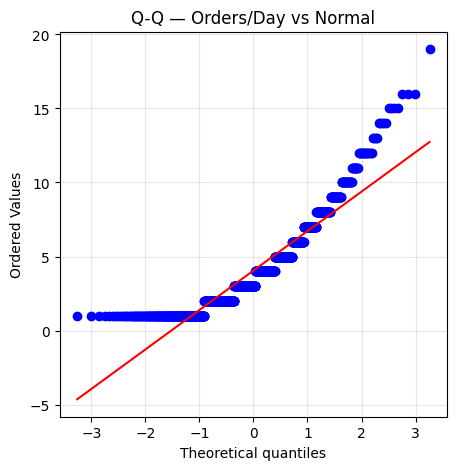

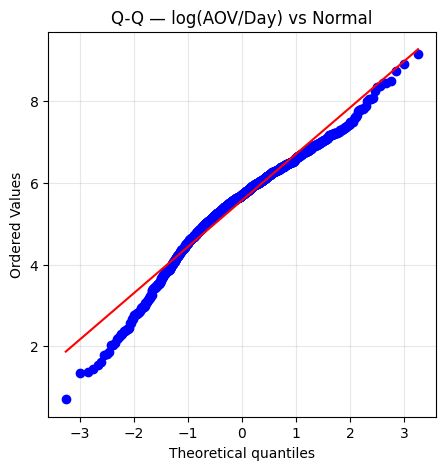

In [ ]:

# --- Distribution diagnostics ---
# Q-Q plots and basic normality/lognormality checks

from scipy import stats

def qq_plot(series, title="Q-Q Plot"):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,5))
    stats.probplot(series.dropna(), dist="norm", plot=plt)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

# Orders/day Q-Q vs Normal
qq_plot(daily['orders_per_day'], "Q-Q — Orders/Day vs Normal")

# AOV/day often right-skewed → check log
qq_plot(np.log(daily['aov_per_day'].dropna()), "Q-Q — log(AOV/Day) vs Normal")



## 4) Monte Carlo Simulation (≥ 10,000)

Choose **sampling_mode**:
- `"empirical"`: bootstrap from `daily` history
- `"parametric"`: Poisson for Orders/day, Lognormal for AOV/day

We'll simulate a **quarter** as 90 days by default.


In [ ]:

# --- Simulation parameters & sampling setup ---
NUM_SIMULATIONS = 10000   # >= 10,000 for the rubric
DAYS = 90                 # ~ one quarter

sampling_mode = "empirical"  # "empirical" or "parametric"

rng = np.random.default_rng(42)  # reproducible

orders_hist = daily['orders_per_day'].dropna().values
aov_hist = daily['aov_per_day'].replace([np.inf, -np.inf], np.nan).dropna().values

if sampling_mode == "parametric":
    # Fit Poisson λ for orders: use mean
    lam_orders = float(np.mean(orders_hist))

    # Fit lognormal for AOV: estimate mu, sigma of log(AOV)
    log_aov = np.log(aov_hist[aov_hist > 0])
    mu_log = float(np.mean(log_aov))
    sigma_log = float(np.std(log_aov, ddof=1))

def sample_day_orders_and_aov(n_days):
    if sampling_mode == "empirical":
        # bootstrap with replacement
        day_orders = rng.choice(orders_hist, size=n_days, replace=True)
        day_aov    = rng.choice(aov_hist,    size=n_days, replace=True)
    else:
        # parametric
        day_orders = rng.poisson(lam=lam_orders, size=n_days)
        day_aov = rng.lognormal(mean=mu_log, sigma=sigma_log, size=n_days)
    return day_orders, day_aov

# --- Run the Monte Carlo ---
quarter_revenues = np.empty(NUM_SIMULATIONS, dtype=float)

for i in range(NUM_SIMULATIONS):
    o, a = sample_day_orders_and_aov(DAYS)
    # Constrain
    o = np.clip(o, 0, None)
    a = np.clip(a, 0, None)
    quarter_revenues[i] = float(np.sum(o * a))

print("Completed {} simulations over {} days each.".format(NUM_SIMULATIONS, DAYS))


Completed 10000 simulations over 90 days each.



## 5) Statistical Analysis

We compute central tendency, spread, confidence intervals, target probabilities, and a simple **VaR (5%)** metric.


In [ ]:

# --- Stats & risk metrics ---
mean_rev = float(np.mean(quarter_revenues))
median_rev = float(np.median(quarter_revenues))
std_rev = float(np.std(quarter_revenues, ddof=1))
p5 = float(np.percentile(quarter_revenues, 5))
p25 = float(np.percentile(quarter_revenues, 25))
p75 = float(np.percentile(quarter_revenues, 75))
p95 = float(np.percentile(quarter_revenues, 95))

# Target example (adjust as needed)
TARGET_REVENUE = 50000.0
prob_meet = float(np.mean(quarter_revenues >= TARGET_REVENUE))

print("RESULTS SUMMARY")
print("===============")
print("Mean: ${:,.2f}".format(mean_rev))
print("Median: ${:,.2f}".format(median_rev))
print("Std Dev: ${:,.2f}".format(std_rev))
print("")
print("90% CI: [${:,.2f}, ${:,.2f}]".format(p5, p95))
print("50% CI: [${:,.2f}, ${:,.2f}]".format(p25, p75))
print("")
print("Probability(Revenue ≥ ${:,.0f}): {:.1%}".format(TARGET_REVENUE, prob_meet))
print("VaR (5% worst case): ${:,.2f}".format(p5))
print("Best Case (max): ${:,.2f}".format(float(np.max(quarter_revenues))))
print("Worst Case (min): ${:,.2f}".format(float(np.min(quarter_revenues))))


RESULTS SUMMARY
Mean: $166,273.03
Median: $161,900.83
Std Dev: $32,016.03

90% CI: [$122,843.41, $225,575.13]
50% CI: [$144,089.32, $183,238.03]

Probability(Revenue ≥ $50,000): 100.0%
VaR (5% worst case): $122,843.41
Best Case (max): $369,107.82
Worst Case (min): $84,875.68



## 6) Visualizations

We include:
- Histogram with key percentiles
- Box plot
- Cumulative distribution (CDF)
- **Extra**: Violin plot (shape + quantiles)


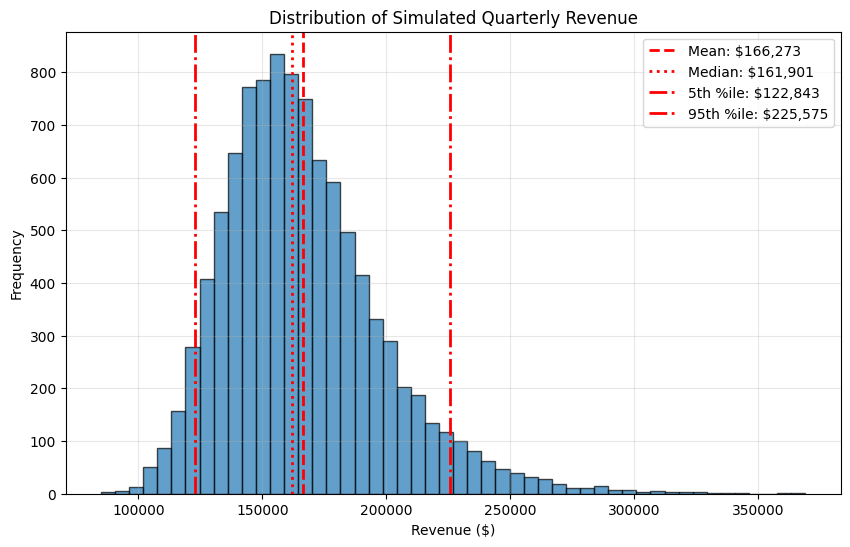

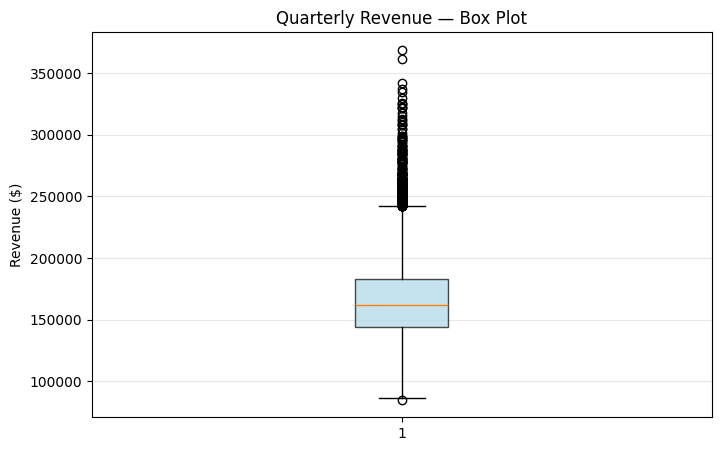

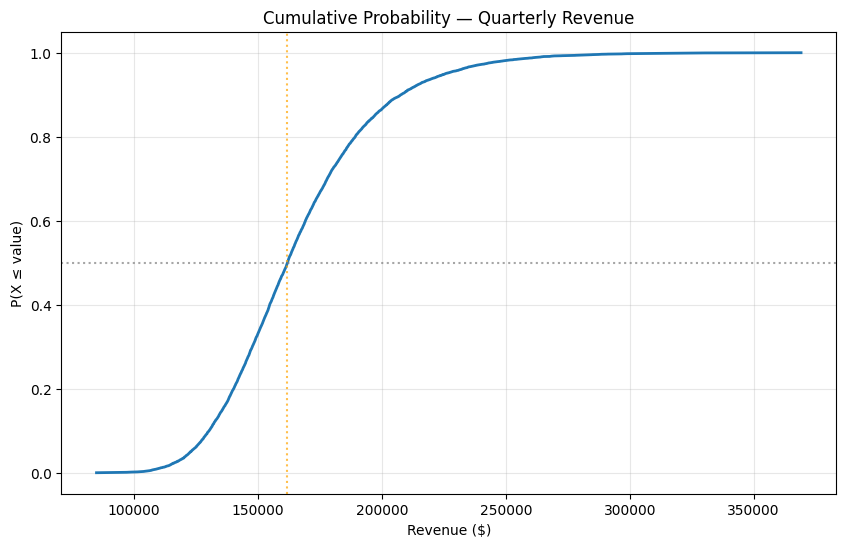

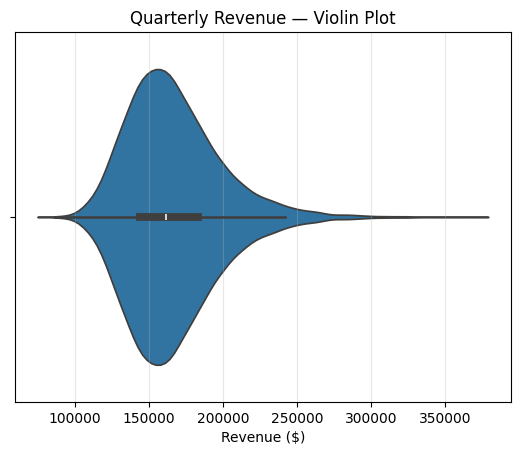

In [ ]:

# --- Histogram with key percentiles ---
plt.figure(figsize=(10,6))
plt.hist(quarter_revenues, bins=50, alpha=0.7, edgecolor='black')
for val, label, style in [(mean_rev, 'Mean', '--'),
                          (median_rev, 'Median', ':'),
                          (p5, '5th %ile', '-.'),
                          (p95, '95th %ile', '-.')]:
    plt.axvline(val, color='red', linestyle=style, linewidth=2, label="{}: ${:,.0f}".format(label, val))
plt.title("Distribution of Simulated Quarterly Revenue")
plt.xlabel("Revenue ($)"); plt.ylabel("Frequency")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# --- Box plot ---
plt.figure(figsize=(8,5))
plt.boxplot(quarter_revenues, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7))
plt.title("Quarterly Revenue — Box Plot")
plt.ylabel("Revenue ($)")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# --- CDF (cumulative) ---
sorted_vals = np.sort(quarter_revenues)
cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
plt.figure(figsize=(10,6))
plt.plot(sorted_vals, cdf, linewidth=2)
plt.axhline(0.5, color='gray', linestyle=':', alpha=0.7)
plt.axvline(median_rev, color='orange', linestyle=':', alpha=0.7)
plt.title("Cumulative Probability — Quarterly Revenue")
plt.xlabel("Revenue ($)"); plt.ylabel("P(X ≤ value)")
plt.grid(alpha=0.3)
plt.show()

# --- Extra: Violin plot ---
sns.violinplot(x=quarter_revenues)
plt.title("Quarterly Revenue — Violin Plot")
plt.xlabel("Revenue ($)")
plt.grid(axis='x', alpha=0.3)
plt.show()



## 7) Interpretation (paste into your Executive Summary)

- **Expected revenue** (mean): `mean_rev`
- **50% interval** (middle half): `[p25 , p75]`
- **90% interval**: `[p5 , p95]`
- **Probability of meeting target** (`TARGET_REVENUE`): `prob_meet`
- **Downside (VaR 5%)**: `p5`

**Decision Guidance:** If the organization is risk-averse, plan for resources consistent with **P10–P25** outcomes and set stretch goals near **P75–P90**. If meeting **TARGET_REVENUE** is critical, consider actions to increase orders/day or AOV (promotions, pricing, cross-sell) and re-run the simulation to assess impact.



---

### Documentation Notes
- **Sampling mode** can be switched to `"parametric"` in the simulation cell.
- **Seasonal filtering**: set `SEASON_MONTHS = [<months>]` (e.g., `[1,2,3]` for Q1) before running.
- **Reproducibility**: controlled via `rng = np.random.default_rng(42)`.
- **Constraints**: Orders and AOV are clipped at zero to avoid negatives.
- **Extensions**: Add correlation between Orders and AOV with multivariate sampling if you observe dependence.
